# Group barcodes to make pseudo-barcodes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def count_group_assignments(df):
    # Number of rows in the DataFrame
    num_rows = len(df)
    
    # Initialize a dictionary to hold the counts for each 15-row chunk
    group_counts_per_chunk = {}

    # Iterate over the DataFrame in chunks of 15 rows
    for start_idx in range(0, num_rows, 15):
        end_idx = start_idx + 15
        chunk = df.iloc[start_idx:end_idx]
        
        # Count the occurrences of each group in this chunk
        counts = chunk['Group'].value_counts().to_dict()
        
        # Store the counts in the dictionary with the chunk's start index as the key
        group_counts_per_chunk[start_idx] = counts

    return group_counts_per_chunk

def sum_barcode_groups(df):
    # Create the "Pseudo-barcode" column
    df['Pseudo-barcode'] = df['enhancer_id'].astype(str) + "_Group_" + df['Group'].astype(str)
    
    # Group by "Pseudo-barcode" and sum numeric columns
    aggregated_df = df.groupby('Pseudo-barcode', as_index=False).sum(numeric_only=True)
    
    # If you need to split the "Pseudo-barcode" back into "enhancer_id" and "Group" or retain these in the aggregated output,
    # it's more efficient to keep them during the aggregation rather than splitting afterwards.
    # However, for simplicity and direct summing, this step is not shown here.
    
    # The result is the aggregated DataFrame with each "Pseudo-barcode" having summed numeric values
    return aggregated_df

def distribute_values_order(df):
    # Assuming 'enhancer_id' is not part of the columns to sum.
    cols_to_sum = [col for col in df.columns if col != 'enhancer_id']
    
    # Calculate the sum across the specified columns for each row.
    df['sum'] = df[cols_to_sum].sum(axis=1)
    
    # Sort the DataFrame based on the 'enhancer_id' and the sum, to keep groups together and in order.
    df = df.sort_values(by=['enhancer_id', 'sum'], ascending=[True, False])
    
    # Function to assign groups within each enhancer_id block.
    def assign_group(x):
        # Calculate ranks within the current block of rows.
        x['Group'] = pd.qcut(x['sum'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
        return x
    
    # Apply the group assignment function to each block of 15 rows.
    df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)
    
    # Drop the temporary 'sum' column used for sorting and ranking.
    df = df.drop(columns=['sum'])
    
    return df


df_index= pd.read_csv("indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv",index_col=0)["enhancer_id"]


In [1]:
def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('D1-', '-').replace('D2-', '-')

# Use sorting method to make pseudo-barcodes for brain RNA (Best, 5 Pseudobarcodes)

In [17]:
import pandas as pd
from pathlib import Path

in_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_filtered.csv")
out_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_filtered_15barcodes.csv")

df = pd.read_csv(in_path)

# Rule: first 986 rows are controls
n_control_rows = 986
df["__row_order__"] = range(len(df))

controls = df.iloc[:n_control_rows].copy()
non_controls = df.iloc[n_control_rows:].copy()

# Define enhancer identity by stripping last ".<barcode>" from ID
# Example: "...#free16-1.1079187" -> "...#free16-1"
def base_enhancer_id(id_str: str) -> str:
    s = str(id_str)
    if "." in s:
        return s.rsplit(".", 1)[0]
    return s

controls["__enhancer_base__"] = controls["ID"].map(base_enhancer_id)

# Keep first 15 barcodes per control enhancer, preserving file order
controls = controls.sort_values("__row_order__", kind="mergesort")
controls["__within_enh__"] = controls.groupby("__enhancer_base__", sort=False).cumcount()
controls_15 = controls.loc[controls["__within_enh__"] < 15].copy()

# Recombine and write
out_df = pd.concat([controls_15, non_controls], axis=0).sort_values("__row_order__", kind="mergesort")
out_df = out_df.drop(columns=["__row_order__"], errors="ignore")
out_df.to_csv(out_path, index=False)

print("Wrote:", out_path)

Wrote: /media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_filtered_15barcodes.csv


In [19]:
import pandas as pd, re
from pathlib import Path

rna_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_RNA_15barcodes.csv")
dna_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_filtered_15barcodes.csv")
out_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2//Brain_DNA_matched_to_RNA_sumD1D2.csv")
rna = pd.read_csv(rna_path, low_memory=False)
dna = pd.read_csv(dna_path, low_memory=False)

# Identify RNA columns in the exact order to match
rna_cols_order = list(rna.columns)

# DNA sample columns are like: ZC102D1-... and ZC102D2-...
dna_sample_cols = [c for c in dna.columns if re.match(r"^ZC\d+D[12]-", str(c))]

pair_pat = re.compile(r"^(ZC\d+)(D[12])-(.+)$")
key_to_cols = {}
for c in dna_sample_cols:
    m = pair_pat.match(str(c))
    if not m:
        continue
    zc, drep, rest = m.group(1), m.group(2), m.group(3)
    key_to_cols.setdefault((zc, rest), {})[drep] = c

# Sum D1 + D2
dna_sum = {}
for (zc, rest), reps in key_to_cols.items():
    if "D1" not in reps or "D2" not in reps:
        continue
    new_col = f"{zc}-{rest}"
    dna_sum[new_col] = (
        pd.to_numeric(dna[reps["D1"]], errors="coerce").fillna(0)
        + pd.to_numeric(dna[reps["D2"]], errors="coerce").fillna(0)
    )
dna_sum = pd.DataFrame(dna_sum)

def extract_ap_and_batch(name: str):
    s = str(name)
    m = re.search(r"(AP\d+)", s)
    if not m:
        return None
    ap = m.group(1)
    m2 = re.search(rf"{ap}[^-]*-(\d+)", s)  # e.g., AP1134misc-26 or AP1134-26-...
    batch = m2.group(1) if m2 else None
    return (ap, batch)

# Map DNA summed columns by (AP, batch)
dna_map = {}
for c in dna_sum.columns:
    k = extract_ap_and_batch(c)
    if k is not None:
        dna_map.setdefault(k, []).append(c)

# Build output with EXACT RNA column order
out = pd.DataFrame(index=rna.index)

# Fill each column following RNA order
for col in rna_cols_order:
    k = extract_ap_and_batch(col)
    if k is not None and k in dna_map:
        # sample column -> use summed DNA matching this AP+batch
        use_dna_col = dna_map[k][0]  # should be unique
        out[col] = dna_sum[use_dna_col].values
    else:
        # metadata/helper column -> copy from RNA if present, else from DNA if present
        if col in rna.columns:
            out[col] = rna[col].values
        elif col in dna.columns:
            out[col] = dna[col].values
        else:
            out[col] = pd.NA

# Sanity check: exact column match
assert list(out.columns) == rna_cols_order

out.to_csv(out_path, index=False)

print("Wrote:", out_path)
print("Columns match RNA exactly:", list(out.columns) == rna_cols_order)
print("Output shape:", out.shape)

Wrote: /media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_matched_to_RNA_sumD1D2.csv
Columns match RNA exactly: True
Output shape: (24465, 38)


/tmp/ipykernel_9003/1171856006.py:7: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(in_path)


Wrote: /media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_matched_to_RNA_sumD1D2_15barcodes.csv


/tmp/ipykernel_9003/1171856006.py:41: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_brain = pd.read_csv("read_counts_R1R2/Brain_DNA_matched_to_RNA_sumD1D2_15barcodes.csv",index_col=0)
/tmp/ipykernel_9003/1171856006.py:76: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_df= df_brain[RNA_columns].groupby(process_column_name, axis=1).sum()
/tmp/ipykernel_9003/1513752992.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)


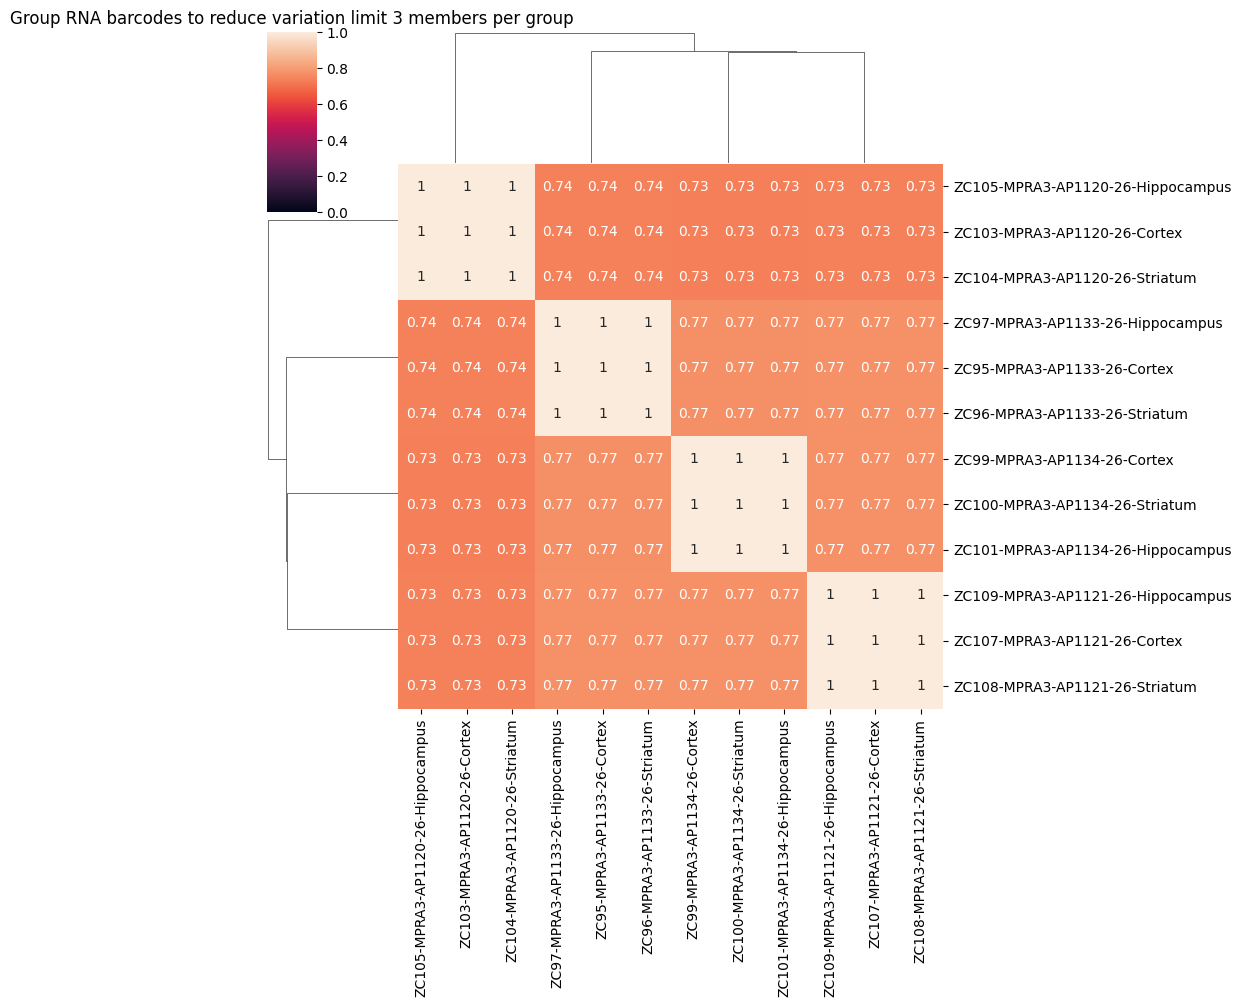

In [4]:
import pandas as pd
from pathlib import Path

in_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_matched_to_RNA_sumD1D2.csv")
out_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_matched_to_RNA_sumD1D2_15barcodes.csv")

df = pd.read_csv(in_path)

# Rule: first 986 rows are controls
n_control_rows = 986
df["__row_order__"] = range(len(df))

controls = df.iloc[:n_control_rows].copy()
non_controls = df.iloc[n_control_rows:].copy()

# Define enhancer identity by stripping last ".<barcode>" from ID
# Example: "...#free16-1.1079187" -> "...#free16-1"
def base_enhancer_id(id_str: str) -> str:
    s = str(id_str)
    if "." in s:
        return s.rsplit(".", 1)[0]
    return s

controls["__enhancer_base__"] = controls["ID"].map(base_enhancer_id)

# Keep first 15 barcodes per control enhancer, preserving file order
controls = controls.sort_values("__row_order__", kind="mergesort")
controls["__within_enh__"] = controls.groupby("__enhancer_base__", sort=False).cumcount()
controls_15 = controls.loc[controls["__within_enh__"] < 15].copy()

# Recombine and write
out_df = pd.concat([controls_15, non_controls], axis=0).sort_values("__row_order__", kind="mergesort")
out_df = out_df.drop(columns=["__row_order__"], errors="ignore")
out_df.to_csv(out_path, index=False)

print("Wrote:", out_path)
#########################################################################################################
# Brain RNA and DNA pseudo-barcodes (5 Pseudobarcodes per enhancer)
import numpy as np
import pandas as pd
df_brain = pd.read_csv("read_counts_R1R2/Brain_DNA_matched_to_RNA_sumD1D2_15barcodes.csv",index_col=0)
RNA_columns=[
'ZC99R-MPRA3-AP1134-26-Cortex',
'ZC99R2-MPRA3-AP1134-26-Cortex',
'ZC100R-MPRA3-AP1134-26-Striatum',
'ZC100R2-MPRA3-AP1134-26-Striatum',
'ZC101R-MPRA3-AP1134-26-Hippocampus',
'ZC101R2-MPRA3-AP1134-26-Hippocampus',

'ZC95R-MPRA3-AP1133-26-Cortex',
'ZC95R2-MPRA3-AP1133-26-Cortex',
'ZC96R-MPRA3-AP1133-26-Striatum',
'ZC96R2-MPRA3-AP1133-26-Striatum',
'ZC97R-MPRA3-AP1133-26-Hippocampus',
'ZC97R2-MPRA3-AP1133-26-Hippocampus',

'ZC103R-MPRA3-AP1120-26-Cortex',
'ZC103R2-MPRA3-AP1120-26-Cortex',
'ZC104R-MPRA3-AP1120-26-Striatum',
'ZC104R2-MPRA3-AP1120-26-Striatum',
'ZC105R-MPRA3-AP1120-26-Hippocampus',
'ZC105R2-MPRA3-AP1120-26-Hippocampus',

'ZC107R-MPRA3-AP1121-26-Cortex',
'ZC107R2-MPRA3-AP1121-26-Cortex',
'ZC108R-MPRA3-AP1121-26-Striatum',
'ZC108R2-MPRA3-AP1121-26-Striatum',
'ZC109R-MPRA3-AP1121-26-Hippocampus',
'ZC109R2-MPRA3-AP1121-26-Hippocampus',
]

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')

grouped_df= df_brain[RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df,df_index,left_index=True, right_index=True)
grouped_df=distribute_values_order(grouped_df)#################


pseudo_barcodes_df = sum_barcode_groups(grouped_df ).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)

import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("enhancer_id",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group RNA barcodes to reduce variation limit 3 members per group")


pseudo_barcodes_df[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes.csv")


Wrote: /media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_RNA_15barcodes.csv


/tmp/ipykernel_9003/534648590.py:41: DtypeWarning: Columns (36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA_15barcodes.csv",index_col=0)
/tmp/ipykernel_9003/534648590.py:76: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_df= df_brain[RNA_columns].groupby(process_column_name, axis=1).sum()
/tmp/ipykernel_9003/1513752992.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)


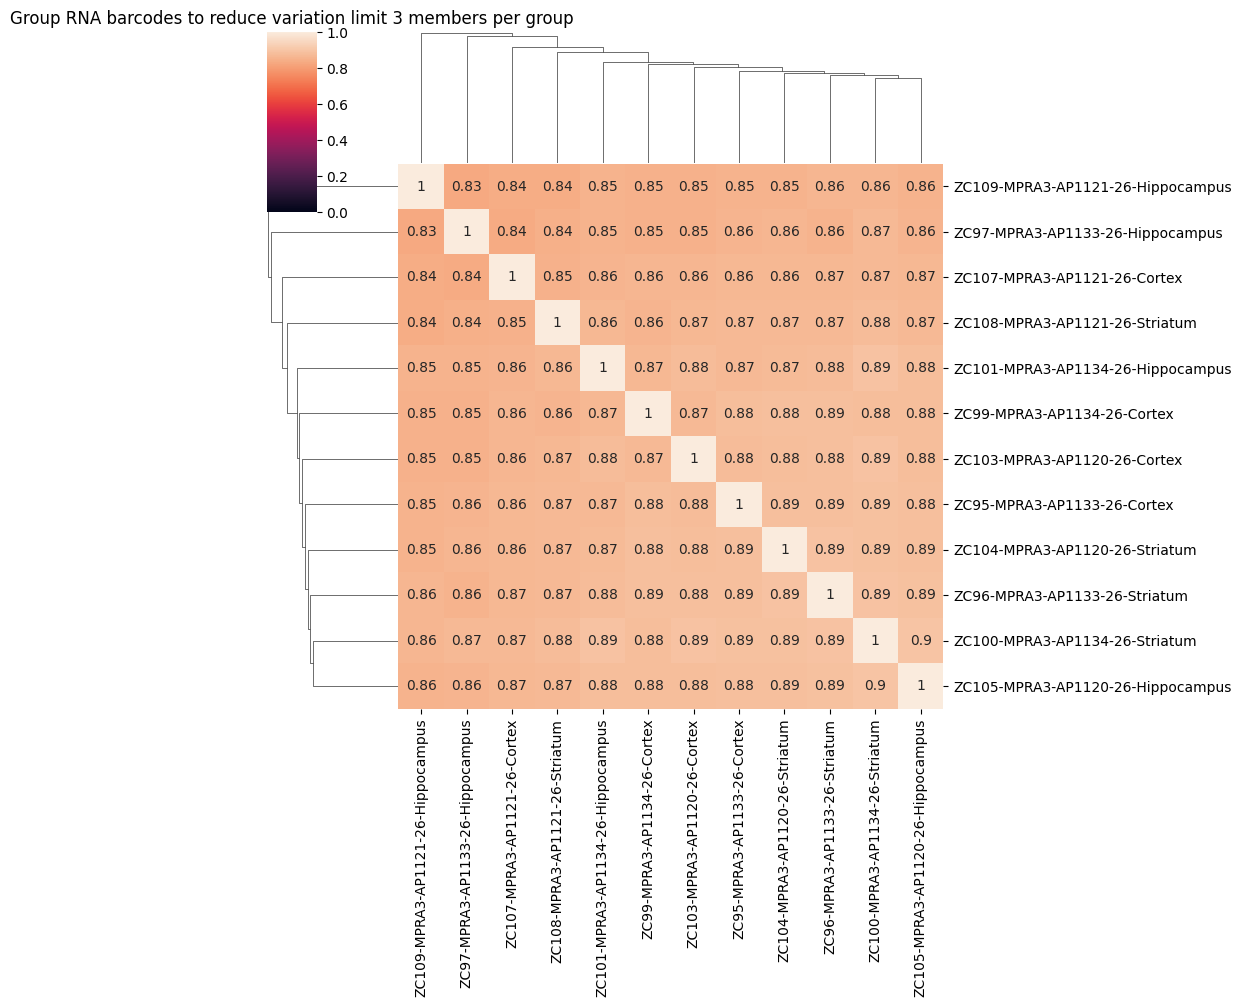

In [3]:
import pandas as pd
from pathlib import Path

in_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_RNA.csv")
out_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_RNA_15barcodes.csv")

df = pd.read_csv(in_path)

# Rule: first 986 rows are controls
n_control_rows = 986
df["__row_order__"] = range(len(df))

controls = df.iloc[:n_control_rows].copy()
non_controls = df.iloc[n_control_rows:].copy()

# Define enhancer identity by stripping last ".<barcode>" from ID
# Example: "...#free16-1.1079187" -> "...#free16-1"
def base_enhancer_id(id_str: str) -> str:
    s = str(id_str)
    if "." in s:
        return s.rsplit(".", 1)[0]
    return s

controls["__enhancer_base__"] = controls["ID"].map(base_enhancer_id)

# Keep first 15 barcodes per control enhancer, preserving file order
controls = controls.sort_values("__row_order__", kind="mergesort")
controls["__within_enh__"] = controls.groupby("__enhancer_base__", sort=False).cumcount()
controls_15 = controls.loc[controls["__within_enh__"] < 15].copy()

# Recombine and write
out_df = pd.concat([controls_15, non_controls], axis=0).sort_values("__row_order__", kind="mergesort")
out_df = out_df.drop(columns=["__row_order__"], errors="ignore")
out_df.to_csv(out_path, index=False)

print("Wrote:", out_path)
#########################################################################################################
# Brain RNA and DNA pseudo-barcodes (5 Pseudobarcodes per enhancer)
import numpy as np
import pandas as pd
df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA_15barcodes.csv",index_col=0)
RNA_columns=[
'ZC99R-MPRA3-AP1134-26-Cortex',
'ZC99R2-MPRA3-AP1134-26-Cortex',
'ZC100R-MPRA3-AP1134-26-Striatum',
'ZC100R2-MPRA3-AP1134-26-Striatum',
'ZC101R-MPRA3-AP1134-26-Hippocampus',
'ZC101R2-MPRA3-AP1134-26-Hippocampus',

'ZC95R-MPRA3-AP1133-26-Cortex',
'ZC95R2-MPRA3-AP1133-26-Cortex',
'ZC96R-MPRA3-AP1133-26-Striatum',
'ZC96R2-MPRA3-AP1133-26-Striatum',
'ZC97R-MPRA3-AP1133-26-Hippocampus',
'ZC97R2-MPRA3-AP1133-26-Hippocampus',

'ZC103R-MPRA3-AP1120-26-Cortex',
'ZC103R2-MPRA3-AP1120-26-Cortex',
'ZC104R-MPRA3-AP1120-26-Striatum',
'ZC104R2-MPRA3-AP1120-26-Striatum',
'ZC105R-MPRA3-AP1120-26-Hippocampus',
'ZC105R2-MPRA3-AP1120-26-Hippocampus',

'ZC107R-MPRA3-AP1121-26-Cortex',
'ZC107R2-MPRA3-AP1121-26-Cortex',
'ZC108R-MPRA3-AP1121-26-Striatum',
'ZC108R2-MPRA3-AP1121-26-Striatum',
'ZC109R-MPRA3-AP1121-26-Hippocampus',
'ZC109R2-MPRA3-AP1121-26-Hippocampus',
]

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')

grouped_df= df_brain[RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df,df_index,left_index=True, right_index=True)
grouped_df=distribute_values_order(grouped_df)#################


pseudo_barcodes_df = sum_barcode_groups(grouped_df ).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)

import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("enhancer_id",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group RNA barcodes to reduce variation limit 3 members per group")


pseudo_barcodes_df[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes.csv")


/tmp/ipykernel_43491/4231671020.py:39: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_df= df_brain.iloc[(986):,:][RNA_columns].groupby(process_column_name, axis=1).sum()
/tmp/ipykernel_43491/1513752992.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)


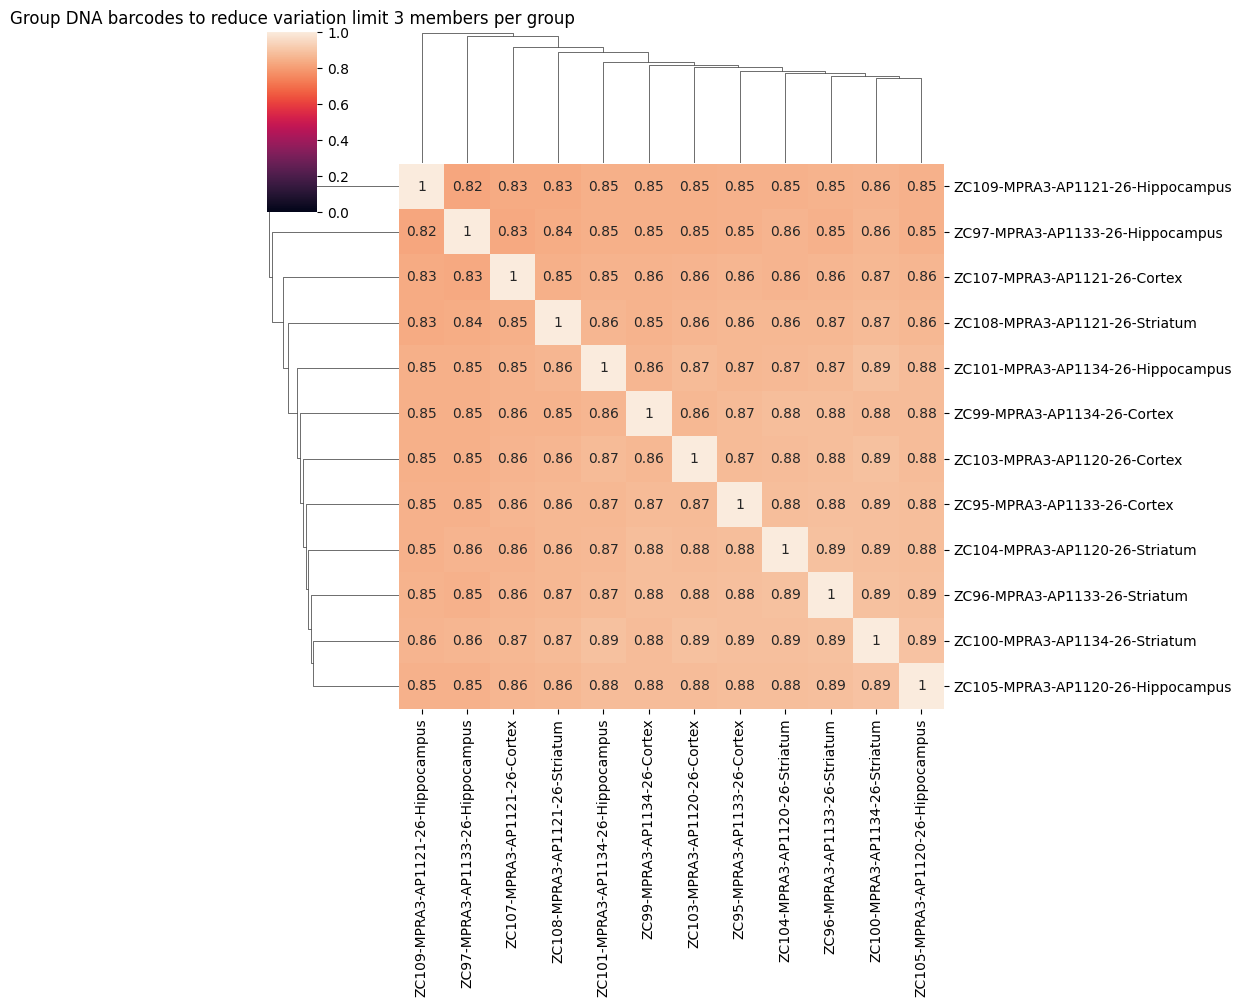

In [ ]:
# Brain RNA and DNA pseudo-barcodes (5 Pseudobarcodes per enhancer)
import numpy as np
import pandas as pd
df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA.csv",index_col=0)
RNA_columns=[
'ZC99R-MPRA3-AP1134-26-Cortex',
'ZC99R2-MPRA3-AP1134-26-Cortex',
'ZC100R-MPRA3-AP1134-26-Striatum',
'ZC100R2-MPRA3-AP1134-26-Striatum',
'ZC101R-MPRA3-AP1134-26-Hippocampus',
'ZC101R2-MPRA3-AP1134-26-Hippocampus',

'ZC95R-MPRA3-AP1133-26-Cortex',
'ZC95R2-MPRA3-AP1133-26-Cortex',
'ZC96R-MPRA3-AP1133-26-Striatum',
'ZC96R2-MPRA3-AP1133-26-Striatum',
'ZC97R-MPRA3-AP1133-26-Hippocampus',
'ZC97R2-MPRA3-AP1133-26-Hippocampus',

'ZC103R-MPRA3-AP1120-26-Cortex',
'ZC103R2-MPRA3-AP1120-26-Cortex',
'ZC104R-MPRA3-AP1120-26-Striatum',
'ZC104R2-MPRA3-AP1120-26-Striatum',
'ZC105R-MPRA3-AP1120-26-Hippocampus',
'ZC105R2-MPRA3-AP1120-26-Hippocampus',

'ZC107R-MPRA3-AP1121-26-Cortex',
'ZC107R2-MPRA3-AP1121-26-Cortex',
'ZC108R-MPRA3-AP1121-26-Striatum',
'ZC108R2-MPRA3-AP1121-26-Striatum',
'ZC109R-MPRA3-AP1121-26-Hippocampus',
'ZC109R2-MPRA3-AP1121-26-Hippocampus',
]

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')

grouped_df= df_brain.iloc[(986):,:][RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df,df_index,left_index=True, right_index=True)
grouped_df=distribute_values_order(grouped_df)#################


pseudo_barcodes_df = sum_barcode_groups(grouped_df ).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)

import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("enhancer_id",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group DNA barcodes to reduce variation limit 3 members per group")


pseudo_barcodes_df[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes.csv")
########################################################################################################################################################
df_cell_DNA_sum = pd.read_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24000.csv",index_col=0)
df_Brain_DNA_fromcell = pd.DataFrame(columns=grouped_df.columns[:-3])
# Copy the Series data multiple times into the DataFrame
for name in df_Brain_DNA_fromcell:
    df_Brain_DNA_fromcell[name] = df_cell_DNA_sum.copy()
df_Brain_DNA_fromcell = pd.merge(df_Brain_DNA_fromcell,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)
df_Brain_DNA_fromcell.to_csv("read_counts_R1R2/BrainR1R2merged20240326_DNA_matched_barcodes.csv")

pseudo_barcodes_df_DNA =  sum_barcode_groups(df_Brain_DNA_fromcell).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df_DNA[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20240404_DNA_matched_barcodes.csv")




In [ ]:
df_cell_DNA_sum = pd.read_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24986.csv",index_col=0)
df_Brain_DNA_fromcell = pd.DataFrame(columns=grouped_df.columns[:-3])
# Copy the Series data multiple times into the DataFrame
for name in df_Brain_DNA_fromcell:
    df_Brain_DNA_fromcell[name] = df_cell_DNA_sum.copy()
df_Brain_DNA_fromcell = pd.merge(df_Brain_DNA_fromcell,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)
#df_Brain_DNA_fromcell.to_csv("read_counts_R1R2/BrainR1R2merged20240326_DNA_matched_barcodes.csv")

pseudo_barcodes_df_DNA =  sum_barcode_groups(df_Brain_DNA_fromcell).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df_DNA[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_pool.csv")


# Make pseudo-bacodes for THP1 macrophage and test the correlation

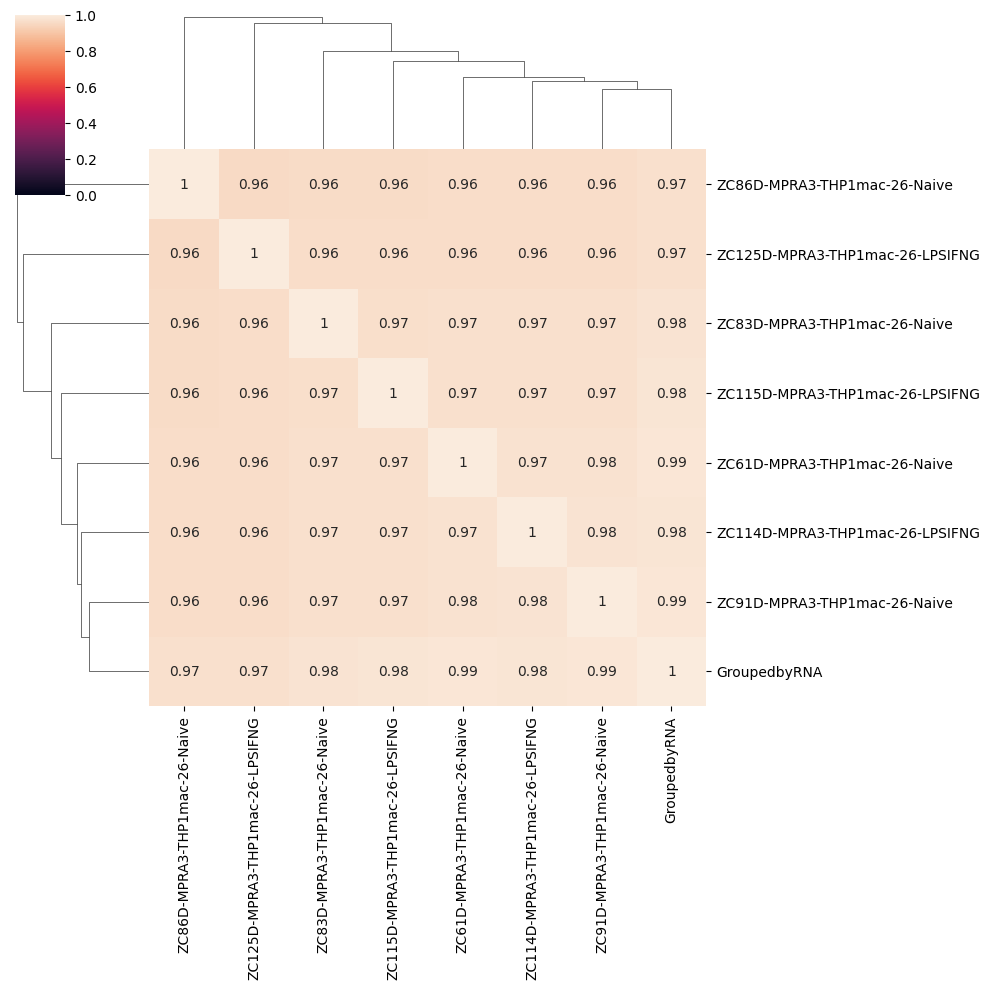

In [79]:
#Use Pseudo-barcodes from Brain on THP1 macrophages and see the correlation
df_THP1 = pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv",index_col=0).iloc[986:,:]
df_THP1_DNA = df_THP1 [['ZC83D-MPRA3-THP1mac-26-Naive',
        'ZC86D-MPRA3-THP1mac-26-Naive',
       'ZC91D-MPRA3-THP1mac-26-Naive', 
        'ZC61D-MPRA3-THP1mac-26-Naive',
       'ZC125D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]
df_DNA_new= pd.merge(df_THP1_DNA,grouped_df[['Group','enhancer_id']],left_index=True,right_index=True)

df_DNA_new_pseudo = sum_barcode_groups(df_DNA_new ).set_index("Pseudo-barcode").sort_index()

df_Brain_DNA_fromcell_grouped = sum_barcode_groups(df_Brain_DNA_fromcell).set_index("Pseudo-barcode").sort_index()[['ZC100-MPRA3-AP1134-26-Striatum']]
df_Brain_DNA_fromcell_grouped.columns=['GroupedbyRNA']
df_DNA_new_pseudo = pd.merge(df_DNA_new_pseudo,df_Brain_DNA_fromcell_grouped,left_index=True,right_index=True)

sns.clustermap(df_DNA_new_pseudo.corr('spearman'),vmin=0,annot=True)

In [84]:
#Process Pseudo-barcodes for THP1 macrophages, both RNA and DNA
df_THP1 = pd.read_csv("read_counts_R1R2/THP1_RNA_matched_barcodes.csv",index_col=0).drop("enhancer_id",axis=1)

df_THP1 = pd.merge(df_THP1,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)


pseudo_barcodes_df_DNA =  sum_barcode_groups(df_THP1).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
mac_column = ['IFNB_THP1mac_ZC58_R', 'IFNB_THP1mac_ZC62_R', 'IFNB_THP1mac_ZC84_R',
       'IFNB_THP1mac_ZC87_R', 'IFNB_THP1mac_ZC92_R', 'IFNG_THP1mac_ZC59_R',
       'IFNG_THP1mac_ZC63_R', 'IFNG_THP1mac_ZC85_R', 'IFNG_THP1mac_ZC88_R',
       'IFNG_THP1mac_ZC93_R', 'LPSIFNG_THP1mac_ZC114_R',
       'LPSIFNG_THP1mac_ZC115_R', 'LPSIFNG_THP1mac_ZC125_R',
       'LPSIFNG_THP1mac_ZC89_R', 'LPSIFNG_THP1mac_ZC94_R',
       'Naive_THP1mac_ZC55_R', 'Naive_THP1mac_ZC56_R', 'Naive_THP1mac_ZC57_R',
       'Naive_THP1mac_ZC61_R', 'Naive_THP1mac_ZC82_R', 'Naive_THP1mac_ZC83_R',
       'Naive_THP1mac_ZC86_R', 'Naive_THP1mac_ZC91_R', 'enhancer_id']
pseudo_barcodes_df_DNA[mac_column].to_csv("read_counts_R1R2/THP1MacrophagePseudobarcodes_RNA_matched_barcodes.csv")

df_THP1 = pd.read_csv("read_counts_R1R2/THP1_DNA_matched_barcodes.csv",index_col=0).drop("enhancer_id",axis=1)

df_THP1 = pd.merge(df_THP1,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)


pseudo_barcodes_df_DNA =  sum_barcode_groups(df_THP1).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
mac_column = ['IFNB_THP1mac_ZC58_R', 'IFNB_THP1mac_ZC62_R', 'IFNB_THP1mac_ZC84_R',
       'IFNB_THP1mac_ZC87_R', 'IFNB_THP1mac_ZC92_R', 'IFNG_THP1mac_ZC59_R',
       'IFNG_THP1mac_ZC63_R', 'IFNG_THP1mac_ZC85_R', 'IFNG_THP1mac_ZC88_R',
       'IFNG_THP1mac_ZC93_R', 'LPSIFNG_THP1mac_ZC114_R',
       'LPSIFNG_THP1mac_ZC115_R', 'LPSIFNG_THP1mac_ZC125_R',
       'LPSIFNG_THP1mac_ZC89_R', 'LPSIFNG_THP1mac_ZC94_R',
       'Naive_THP1mac_ZC55_R', 'Naive_THP1mac_ZC56_R', 'Naive_THP1mac_ZC57_R',
       'Naive_THP1mac_ZC61_R', 'Naive_THP1mac_ZC82_R', 'Naive_THP1mac_ZC83_R',
       'Naive_THP1mac_ZC86_R', 'Naive_THP1mac_ZC91_R', 'enhancer_id']
pseudo_barcodes_df_DNA[mac_column].to_csv("read_counts_R1R2/THP1MacrophagePseudobarcodes_DNA_matched_barcodes.csv")


# Brain RNA and DNA pseudo-barcodes (3 Pseudobarcodes per enhancer)

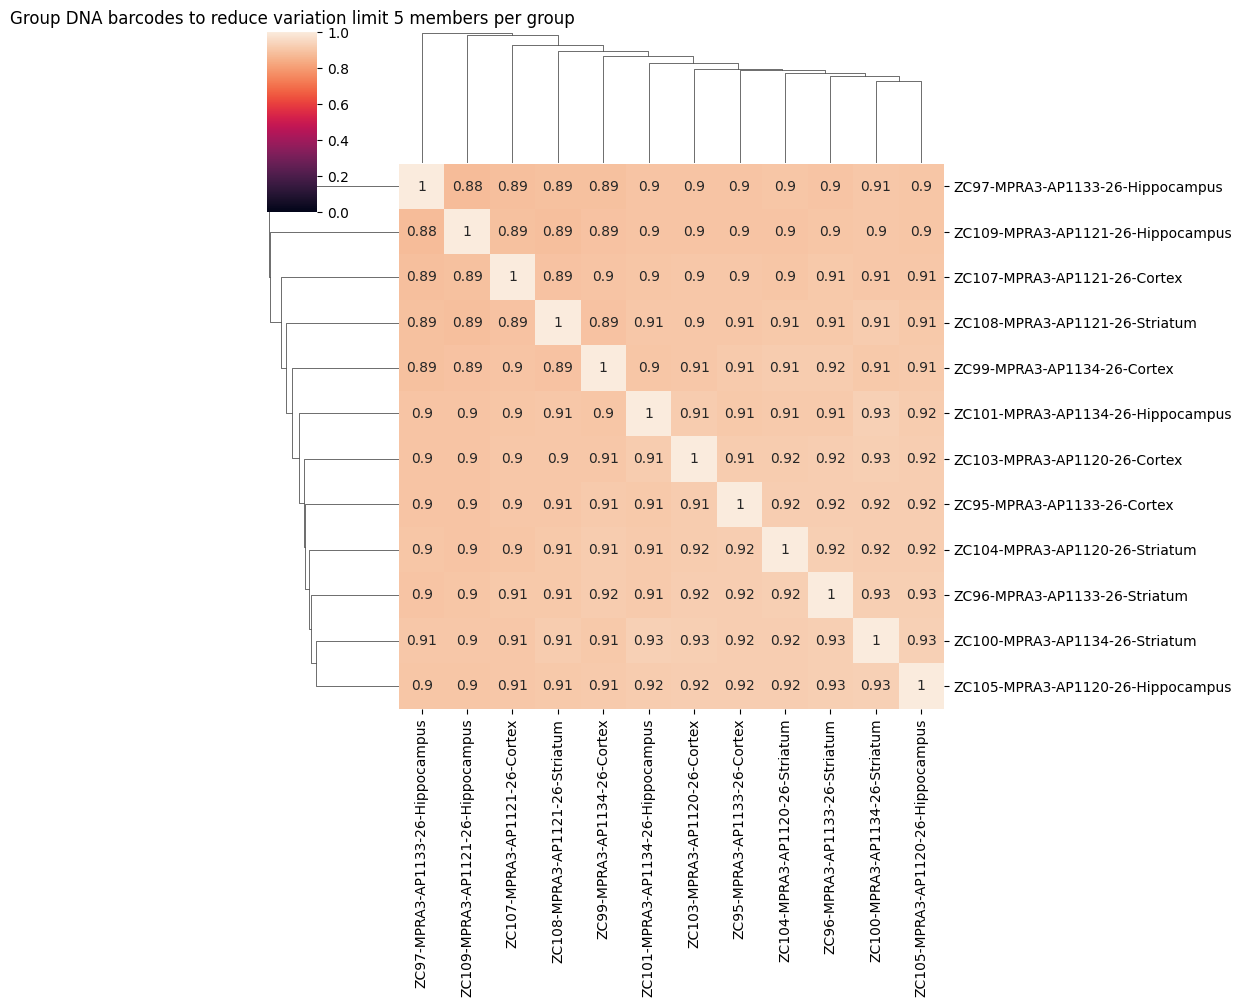

In [4]:
# Brain RNA and DNA pseudo-barcodes (3 Pseudobarcodes per enhancer)
def distribute_values_order(df):
    # Assuming 'enhancer_id' is not part of the columns to sum.
    cols_to_sum = [col for col in df.columns if col != 'enhancer_id']
    
    # Calculate the sum across the specified columns for each row.
    df['sum'] = df[cols_to_sum].sum(axis=1)
    
    # Sort the DataFrame based on the 'enhancer_id' and the sum, to keep groups together and in order.
    df = df.sort_values(by=['enhancer_id', 'sum'], ascending=[True, False])
    
    # Function to assign groups within each enhancer_id block.
    def assign_group(x):
        # Calculate ranks within the current block of rows.
        x['Group'] = pd.qcut(x['sum'].rank(method='first'), 3, labels=[1, 2, 3])
        return x
    
    # Apply the group assignment function to each block of 15 rows.
    df = df.groupby('enhancer_id', group_keys=False).apply(assign_group)
    
    # Drop the temporary 'sum' column used for sorting and ranking.
    df = df.drop(columns=['sum'])
    
    return df


df_index= pd.read_csv("indexing/MPRA3_Contributor_20231108_unique_GeneName_BarcodeEnhancerPair.csv",index_col=0)["enhancer_id"]

import numpy as np
import pandas as pd
df_brain = pd.read_csv("read_counts_R1R2/Brain_RNA.csv",index_col=0)
RNA_columns=[
'ZC99R-MPRA3-AP1134-26-Cortex',
'ZC99R2-MPRA3-AP1134-26-Cortex',
'ZC100R-MPRA3-AP1134-26-Striatum',
'ZC100R2-MPRA3-AP1134-26-Striatum',
'ZC101R-MPRA3-AP1134-26-Hippocampus',
'ZC101R2-MPRA3-AP1134-26-Hippocampus',

'ZC95R-MPRA3-AP1133-26-Cortex',
'ZC95R2-MPRA3-AP1133-26-Cortex',
'ZC96R-MPRA3-AP1133-26-Striatum',
'ZC96R2-MPRA3-AP1133-26-Striatum',
'ZC97R-MPRA3-AP1133-26-Hippocampus',
'ZC97R2-MPRA3-AP1133-26-Hippocampus',

'ZC103R-MPRA3-AP1120-26-Cortex',
'ZC103R2-MPRA3-AP1120-26-Cortex',
'ZC104R-MPRA3-AP1120-26-Striatum',
'ZC104R2-MPRA3-AP1120-26-Striatum',
'ZC105R-MPRA3-AP1120-26-Hippocampus',
'ZC105R2-MPRA3-AP1120-26-Hippocampus',

'ZC107R-MPRA3-AP1121-26-Cortex',
'ZC107R2-MPRA3-AP1121-26-Cortex',
'ZC108R-MPRA3-AP1121-26-Striatum',
'ZC108R2-MPRA3-AP1121-26-Striatum',
'ZC109R-MPRA3-AP1121-26-Hippocampus',
'ZC109R2-MPRA3-AP1121-26-Hippocampus',
]

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')

grouped_df= df_brain.iloc[(986):,:][RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df,df_index,left_index=True, right_index=True)
grouped_df=distribute_values_order(grouped_df)


pseudo_barcodes_df = sum_barcode_groups(grouped_df ).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)

import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("enhancer_id",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group DNA barcodes to reduce variation limit 5 members per group")


pseudo_barcodes_df[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20240416_RNA_matched_barcodes.csv")
########################################################################################################################################################
df_cell_DNA_sum = pd.read_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24000.csv",index_col=0)
df_Brain_DNA_fromcell = pd.DataFrame(columns=grouped_df.columns[:-3])
# Copy the Series data multiple times into the DataFrame
for name in df_Brain_DNA_fromcell:
    df_Brain_DNA_fromcell[name] = df_cell_DNA_sum.copy()
df_Brain_DNA_fromcell = pd.merge(df_Brain_DNA_fromcell,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)
df_Brain_DNA_fromcell.to_csv("read_counts_R1R2/BrainR1R2merged20240326_DNA_matched_barcodes.csv")

pseudo_barcodes_df_DNA =  sum_barcode_groups(df_Brain_DNA_fromcell).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df_DNA[[ 'ZC100-MPRA3-AP1134-26-Striatum',
       'ZC101-MPRA3-AP1134-26-Hippocampus', 'ZC103-MPRA3-AP1120-26-Cortex',
       'ZC104-MPRA3-AP1120-26-Striatum', 'ZC105-MPRA3-AP1120-26-Hippocampus',
       'ZC107-MPRA3-AP1121-26-Cortex', 'ZC108-MPRA3-AP1121-26-Striatum',
       'ZC109-MPRA3-AP1121-26-Hippocampus', 'ZC95-MPRA3-AP1133-26-Cortex',
       'ZC96-MPRA3-AP1133-26-Striatum', 'ZC97-MPRA3-AP1133-26-Hippocampus',
       'ZC99-MPRA3-AP1134-26-Cortex','enhancer_id']].to_csv("read_counts_R1R2/BrainR1R2merged20240416_DNA_matched_barcodes.csv")


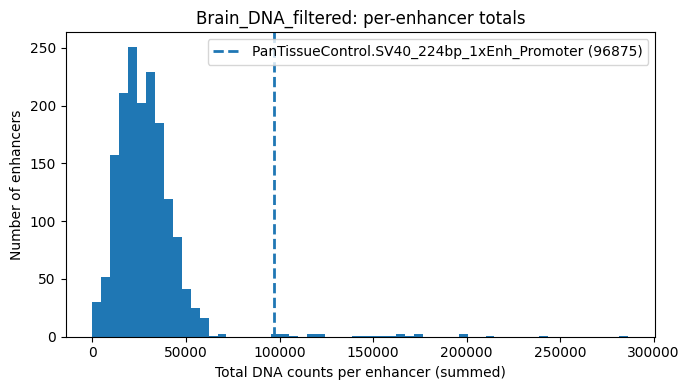

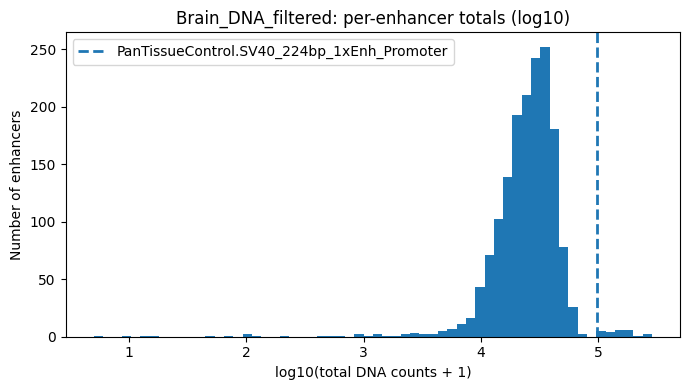

PanTissueControl.SV40_224bp_1xEnh_Promoter total = 96875.0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    "/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/Brain_DNA_filtered.csv",
    index_col=0
)

# total DNA counts per enhancer (sum numeric columns within enhancer, then sum across columns)
per_enh = df.groupby("enhancer_id").sum(numeric_only=True).sum(axis=1)

control_id = "PanTissueControl.SV40_224bp_1xEnh_Promoter"
control_val = per_enh.get(control_id, None)

# --- linear-scale histogram ---
plt.figure(figsize=(7, 4))
plt.hist(per_enh.values, bins=60)
if control_val is not None:
    plt.axvline(control_val, linestyle="--", linewidth=2, label=f"{control_id} ({control_val:.0f})")
    plt.legend()
plt.xlabel("Total DNA counts per enhancer (summed)")
plt.ylabel("Number of enhancers")
plt.title("Brain_DNA_filtered: per-enhancer totals")
plt.tight_layout()
plt.show()

# --- optional: log10 histogram (often clearer for heavy tails) ---
x = np.log10(per_enh.values + 1)
plt.figure(figsize=(7, 4))
plt.hist(x, bins=60)
if control_val is not None:
    plt.axvline(np.log10(control_val + 1), linestyle="--", linewidth=2, label=f"{control_id}")
    plt.legend()
plt.xlabel("log10(total DNA counts + 1)")
plt.ylabel("Number of enhancers")
plt.title("Brain_DNA_filtered: per-enhancer totals (log10)")
plt.tight_layout()
plt.show()

if control_val is None:
    print(f"WARNING: '{control_id}' not found in per_enh index.")
else:
    print(f"{control_id} total = {control_val}")


# Make pseudo-bacodes for Gut and test the correlation

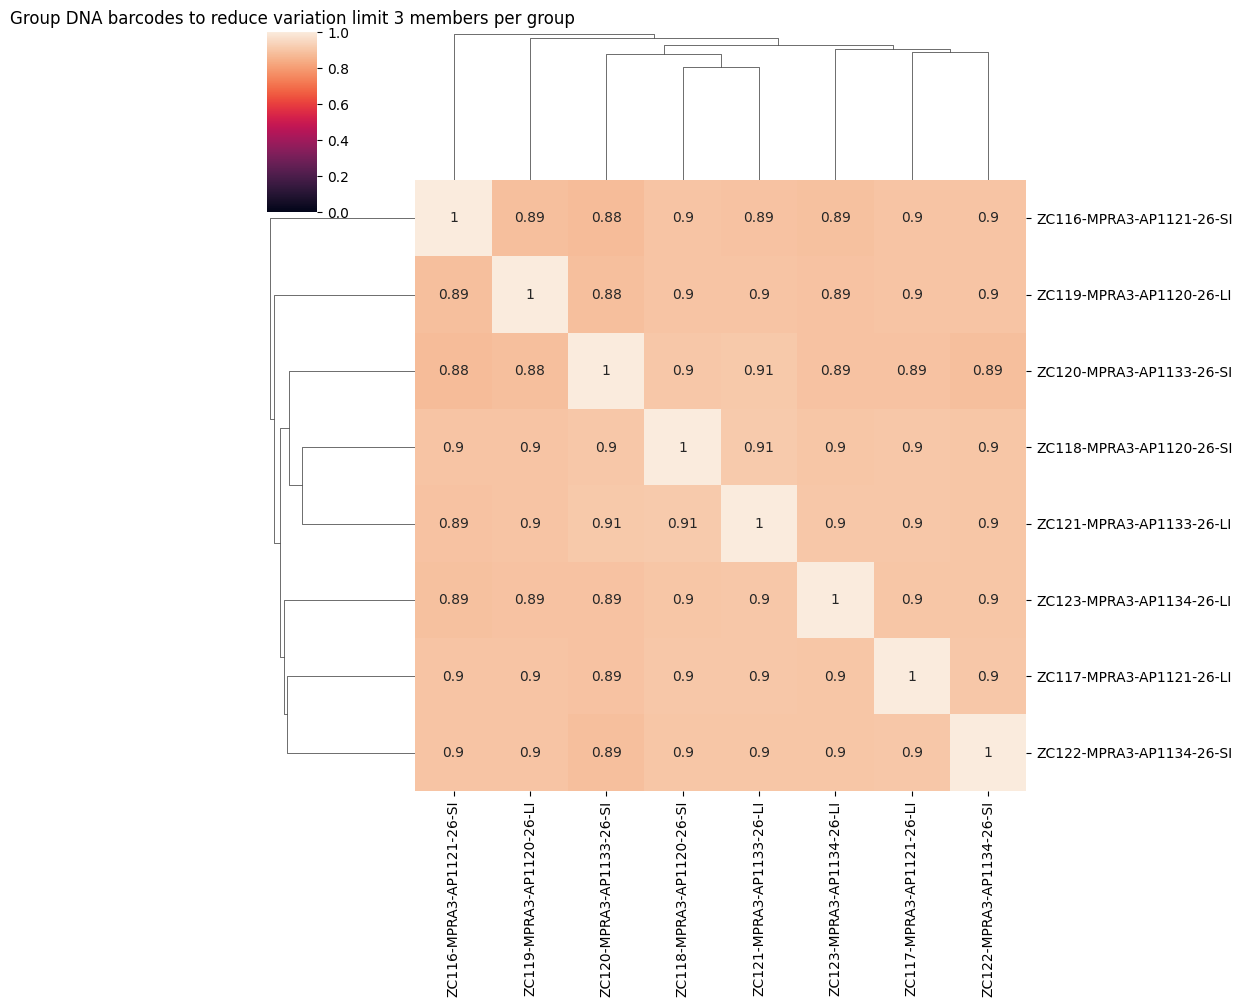

In [3]:
#Gut uses a different grouping from brain and THP1 monocytes
import numpy as np
import pandas as pd

def process_column_name(name):
    # Removing characters that differentiate the columns (like R and R2 in this case)
    return name.replace('R-', '-').replace('R2-', '-')
df_gut = pd.read_csv("read_counts_R1R2/Gut_RNA_technicalReplicates.csv",index_col=0)

RNA_columns = ['ZC116R-MPRA3-AP1121-26-SI', 'ZC116R2-MPRA3-AP1121-26-SI',
       'ZC118R-MPRA3-AP1120-26-SI', 'ZC118R2-MPRA3-AP1120-26-SI',
       'ZC120R-MPRA3-AP1133-26-SI', 'ZC120R2-MPRA3-AP1133-26-SI',
       'ZC122R-MPRA3-AP1134-26-SI', 'ZC122R2-MPRA3-AP1134-26-SI',
       'ZC117R-MPRA3-AP1121-26-LI', 'ZC117R2-MPRA3-AP1121-26-LI',
       'ZC119R-MPRA3-AP1120-26-LI', 'ZC119R2-MPRA3-AP1120-26-LI',
       'ZC121R-MPRA3-AP1133-26-LI', 'ZC121R2-MPRA3-AP1133-26-LI',
       'ZC123R-MPRA3-AP1134-26-LI', 'ZC123R2-MPRA3-AP1134-26-LI',]
grouped_df= df_gut.iloc[(986):,:][RNA_columns].groupby(process_column_name, axis=1).sum()
grouped_df = pd.merge(grouped_df,df_index,left_index=True, right_index=True)
grouped_df=distribute_values_order(grouped_df)

pseudo_barcodes_df = sum_barcode_groups(grouped_df ).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)

import matplotlib.pyplot as plt
sns.clustermap(pseudo_barcodes_df.drop("enhancer_id",axis=1).corr('spearman'),vmin=0,annot=True)
plt.title("Group DNA barcodes to reduce variation limit 3 members per group")
pseudo_barcodes_df.to_csv("read_counts_R1R2/GutR1R2merged20240404_RNA_matched_barcodes.csv")
###########################################################################################################################################
df_cell_DNA_sum = pd.read_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24000.csv",index_col=0)
df_Brain_DNA_fromcell = pd.DataFrame(columns=grouped_df.columns[:-3])
# Copy the Series data multiple times into the DataFrame
for name in df_Brain_DNA_fromcell:
    df_Brain_DNA_fromcell[name] = df_cell_DNA_sum.copy()
df_Brain_DNA_fromcell = pd.merge(df_Brain_DNA_fromcell,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)
#df_Brain_DNA_fromcell.to_csv("read_counts_R1R2/BrainR1R2merged20240326_DNA_matched_barcodes.csv")

pseudo_barcodes_df_DNA =  sum_barcode_groups(df_Brain_DNA_fromcell).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df_DNA.to_csv("read_counts_R1R2/GutR1R2merged20240404_DNA_matched_barcodes.csv")

# Make combined DNA counts

In [ ]:
df_THP1_DNA =  pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv",index_col=0)[[
       'ZC83D-MPRA3-THP1mac-26-Naive',
       'ZC86D-MPRA3-THP1mac-26-Naive',
       'ZC91D-MPRA3-THP1mac-26-Naive', 
       'ZC61D-MPRA3-THP1mac-26-Naive',
       'ZC125D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]

df_HMC3 = pd.read_csv("read_counts_R1R2/HMC3_DNA_RNA.csv",index_col=0)
df_HMC3 = df_HMC3[[
       'ZC22-24D-MPRA3-HMC3-26-Stim', 
       'ZC2D-MPRA3-HMC3-26-Naive', 
       'ZC3-5D-MPRA3-HMC3-26-Stim',
       'ZC67D-MPRA3-HMC3-26-Naive',  
       'ZC72D-MPRA3-HMC3-26-Naive',
       'ZC77D-MPRA3-HMC3-26-Naive', ]]

df_HEK = pd.read_csv("read_counts_R1R2/HEK293T_DNA_RNA.csv",index_col=0)
df_HEK = df_HEK[[
       'ZC65D-MPRA3-HEK293T-26-Naive',
       'ZC66D-MPRA3-HEK293T-26-Naive', 'ZC71D-MPRA3-HEK293T-26-Naive',
       'ZC76D-MPRA3-HEK293T-26-Naive', 'ZC81D-MPRA3-HEK293T-26-Naive']]


print(df_HMC3.shape,df_HMC3.shape,df_THP1_DNA.shape)
df_cell = pd.merge(df_HMC3,df_THP1_DNA,left_index=True,right_index=True)
df_cell = pd.merge(df_HEK,df_cell ,left_index=True,right_index=True)

df_cell.sum()
df_cell_keep = df_cell.drop("ZC65D-MPRA3-HEK293T-26-Naive",axis=1)#.iloc[15:]
df_cell_keep_norm = (df_cell_keep/df_cell_keep.sum()*10**6)
df_cell_keep_norm_sum = round(df_cell_keep_norm.sum(axis=1)*(10))
df_cell_keep_norm_sum.to_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24986.csv")
print("sum shape", df_cell_keep_norm_sum.shape)



(24986, 6) (24986, 6) (24986, 7)
sum shape (24986,)


(24000, 6) (24000, 6) (24000, 7)
sum shape (24000,)


(0.0, 200.0)

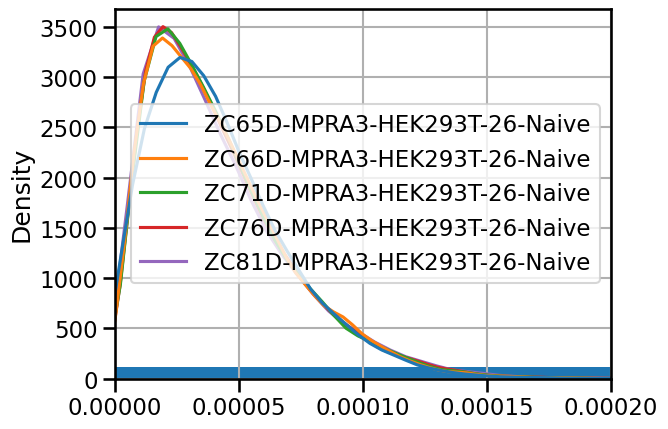

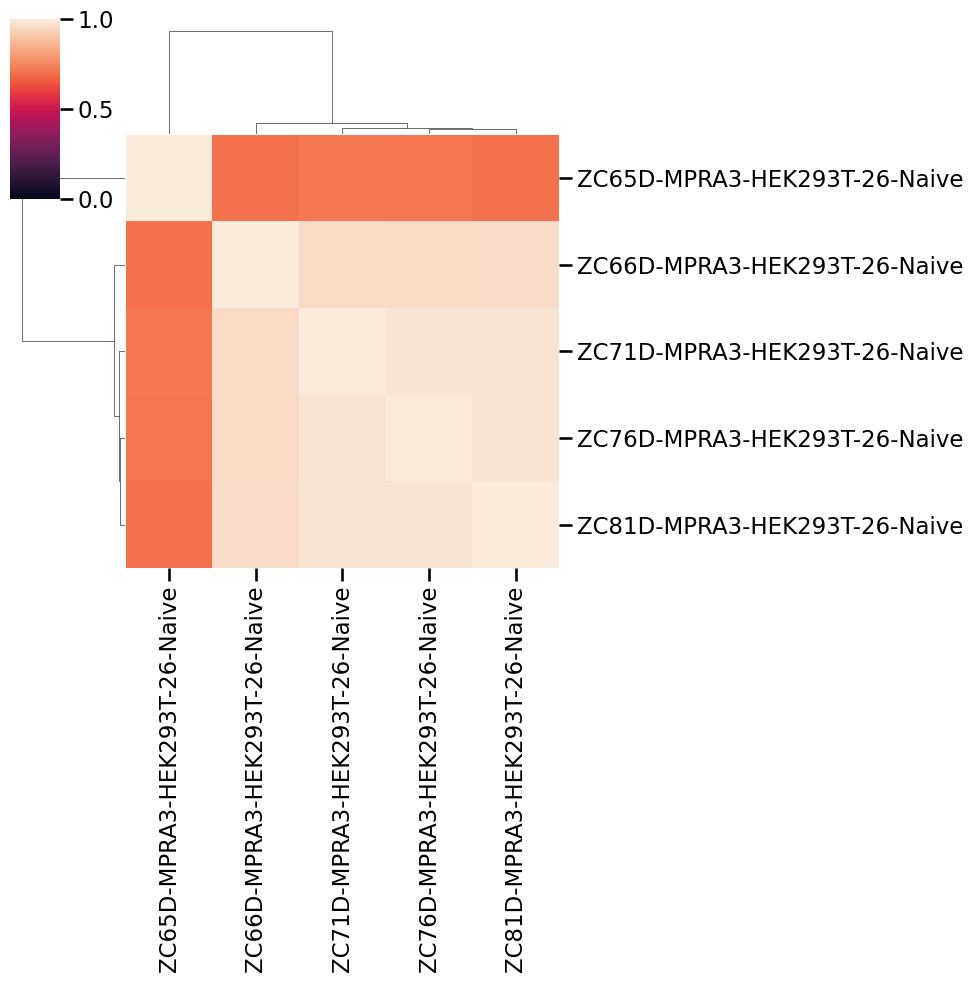

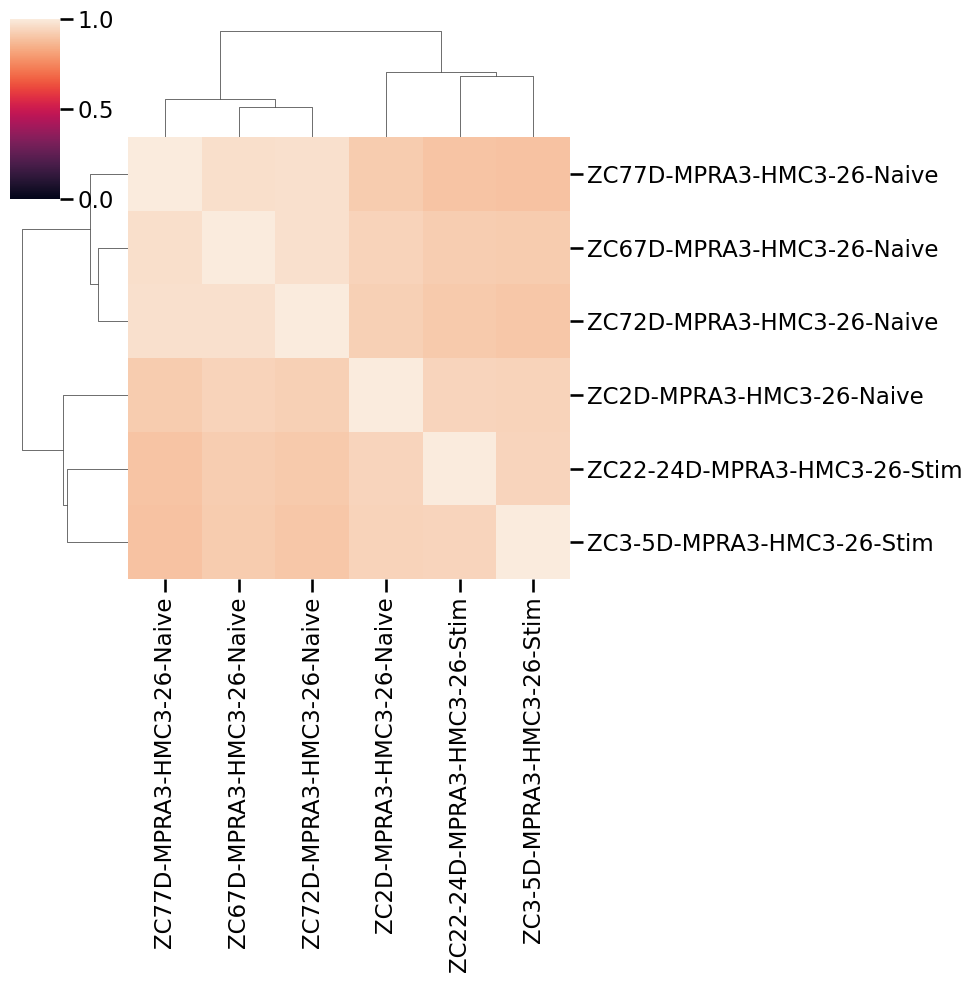

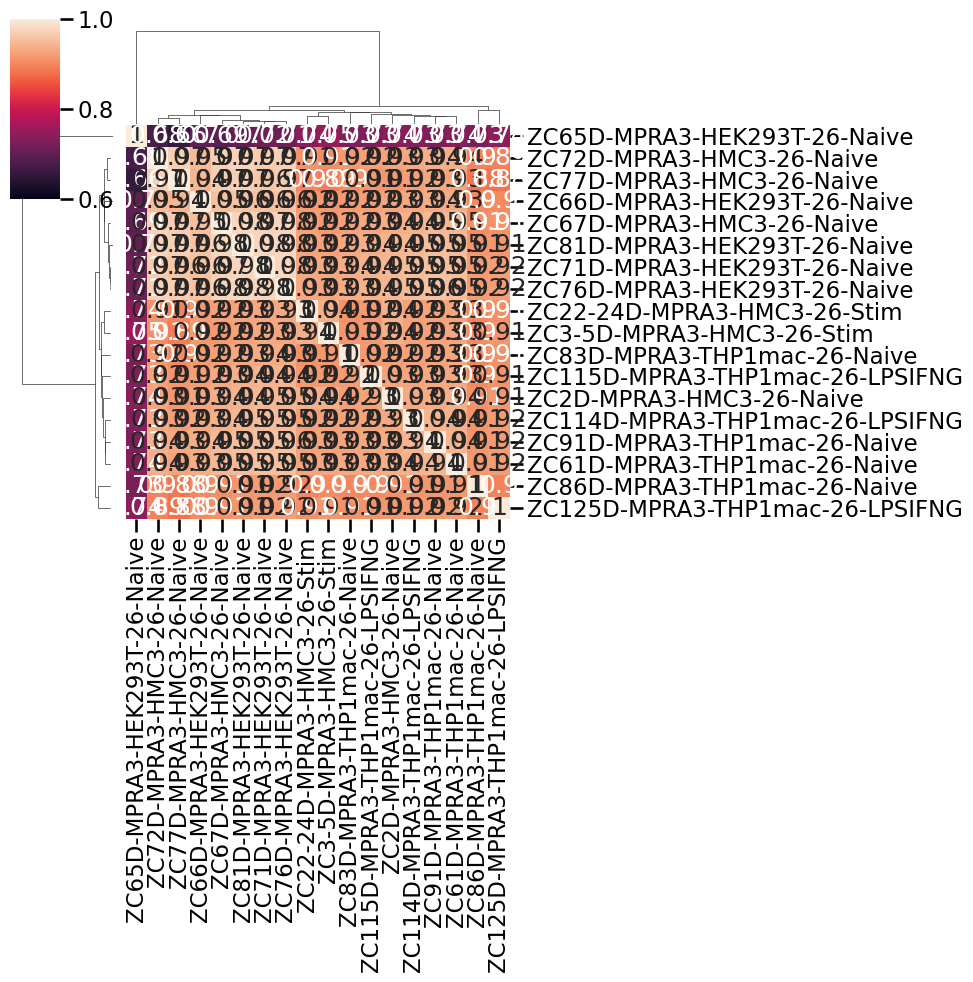

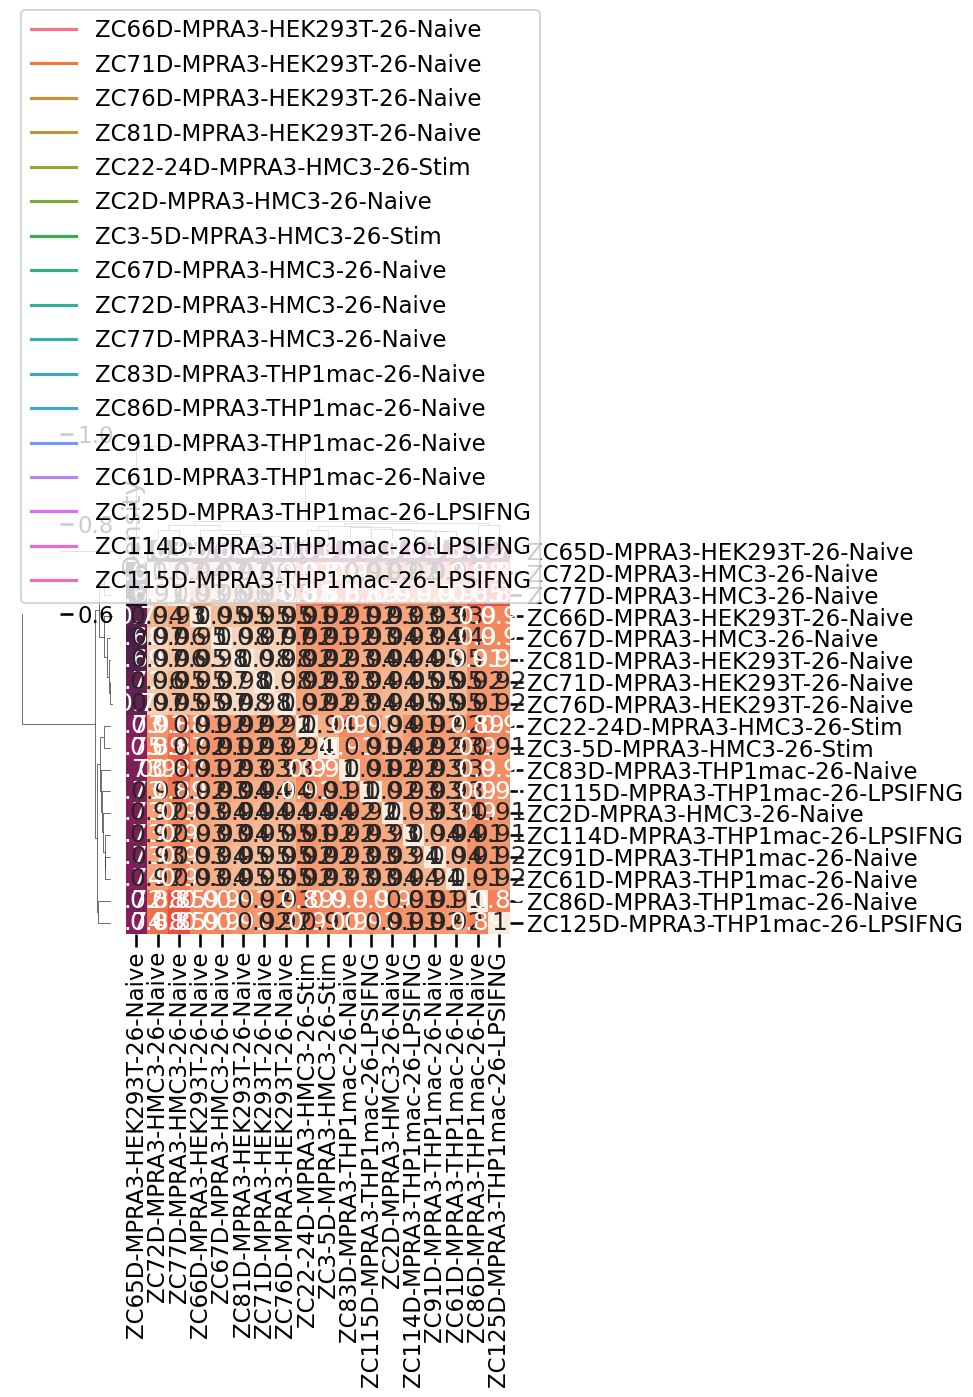

In [ ]:
df_THP1_DNA =  pd.read_csv("read_counts_R1R2/THP1_DNA_RNA.csv",index_col=0).iloc[986:,:][['ZC83D-MPRA3-THP1mac-26-Naive',
        'ZC86D-MPRA3-THP1mac-26-Naive',
       'ZC91D-MPRA3-THP1mac-26-Naive', 
        'ZC61D-MPRA3-THP1mac-26-Naive',
       'ZC125D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG',
       'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]


df_THP1_DNA.sum(axis=1).hist(bins=1000)

df_HEK = pd.read_csv("read_counts_R1R2/HEK293T_DNA_RNA.csv",index_col=0).iloc[986:,:]
df_HEK = df_HEK[['ZC65D-MPRA3-HEK293T-26-Naive',
       'ZC66D-MPRA3-HEK293T-26-Naive', 'ZC71D-MPRA3-HEK293T-26-Naive',
       'ZC76D-MPRA3-HEK293T-26-Naive', 'ZC81D-MPRA3-HEK293T-26-Naive']]

import seaborn as sns
sns.kdeplot(data=df_HEK/df_HEK.sum())
plt.xlim(0,0.0002)

sns.clustermap(df_HEK.iloc[15:].corr('spearman'),vmin=0)

df_HMC3 = pd.read_csv("read_counts_R1R2/HMC3_DNA_RNA.csv",index_col=0).iloc[986:,:]
df_HMC3 = df_HMC3[['ZC22-24D-MPRA3-HMC3-26-Stim', 
       'ZC2D-MPRA3-HMC3-26-Naive', 
       'ZC3-5D-MPRA3-HMC3-26-Stim',
       'ZC67D-MPRA3-HMC3-26-Naive',  'ZC72D-MPRA3-HMC3-26-Naive',
       'ZC77D-MPRA3-HMC3-26-Naive', ]]
sns.clustermap(df_HMC3.corr('spearman'),vmin=0)
df_HMC3.sum()/1000000

print(df_HMC3.shape,df_HMC3.shape,df_THP1_DNA.shape)
df_cell = pd.merge(df_HMC3,df_THP1_DNA,left_index=True,right_index=True)
df_cell = pd.merge(df_HEK,df_cell ,left_index=True,right_index=True)
sns.clustermap(df_cell.iloc[15:].corr('spearman'),vmin=0.6,annot=True)
sns.clustermap(df_cell.iloc[15:].corr('pearson'),vmin=0.6,annot=True)
df_cell.sum()
df_cell_keep = df_cell.drop("ZC65D-MPRA3-HEK293T-26-Naive",axis=1)#.iloc[15:]
df_cell_keep_norm = (df_cell_keep/df_cell_keep.sum()*10**6)
df_cell_keep_norm_sum = round(df_cell_keep_norm.sum(axis=1)*(10))
#df_cell_keep_norm_sum.to_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24000.csv")
print("sum shape", df_cell_keep_norm_sum.shape)

import seaborn as sns

plt.xlim(0,200)
df_cell_keep = df_cell.drop("ZC65D-MPRA3-HEK293T-26-Naive",axis=1)#.iloc[15:]
df_cell_keep_norm = (df_cell_keep/df_cell_keep.sum()*10**6)
df_cell_keep_norm_sum = round(df_cell_keep_norm.sum(axis=1)*(10))
#df_cell_keep_norm_sum.to_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24000.csv")

sns.kdeplot(data=df_cell_keep_norm)
plt.xlim(0,200)

-2.0082077492464165

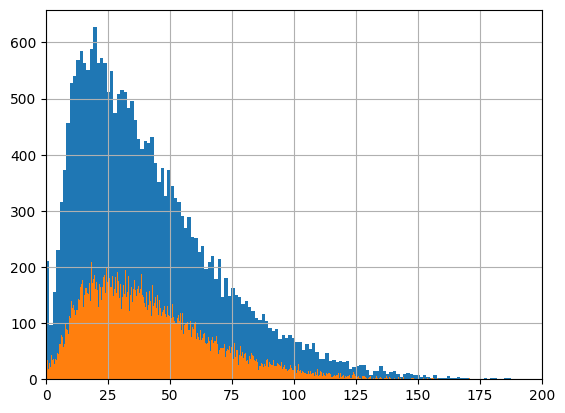

In [14]:


df_cluster1 = df_cell[['ZC66D-MPRA3-HEK293T-26-Naive',
       'ZC71D-MPRA3-HEK293T-26-Naive', 'ZC76D-MPRA3-HEK293T-26-Naive',
       'ZC67D-MPRA3-HMC3-26-Naive', 'ZC72D-MPRA3-HMC3-26-Naive',
       'ZC77D-MPRA3-HMC3-26-Naive', 'ZC83D-MPRA3-THP1mac-26-Naive',
]]#.iloc[15:]
df_cluster2 = df_cell[['ZC22-24D-MPRA3-HMC3-26-Stim', 'ZC3-5D-MPRA3-HMC3-26-Stim',
 'ZC83D-MPRA3-THP1mac-26-Naive',
 'ZC91D-MPRA3-THP1mac-26-Naive',
       'ZC61D-MPRA3-THP1mac-26-Naive', 
       'ZC114D-MPRA3-THP1mac-26-LPSIFNG', 'ZC115D-MPRA3-THP1mac-26-LPSIFNG']]#.iloc[15:]
df_cluster1_sum = (df_cluster1.sum(axis=1)/df_cluster1.sum(axis=1).sum())*1000000
df_cluster2_sum = (df_cluster2.sum(axis=1)/df_cluster2.sum(axis=1).sum())*1000000

df_cluster1_sum.iloc[:15]
df_cluster2_sum.iloc[:15]

(df_cluster1.sum(axis=1)/df_cluster1.sum(axis=1).sum()*1000000).hist(bins=500)
#(df_cluster2.sum(axis=1)/df_cluster2.sum(axis=1).sum()).hist(bins=500)
(df_cluster2.sum(axis=1)/df_cluster2.sum(axis=1).sum()*1000000).hist(bins=500)
plt.xlim(0,200)
df_cluster1_sum.mean()-df_cluster2_sum.mean()
df_cluster1_sum.median()-df_cluster2_sum.median()
################SV40 the outlier causes this figure

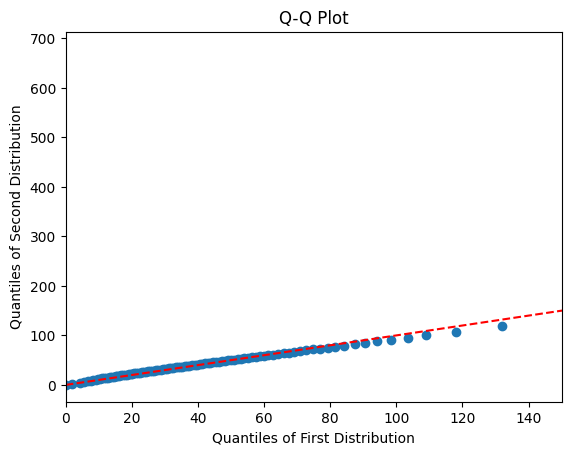

In [15]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate two distributions (for demonstration)
data1 = np.random.normal(0, 1, 24000)  # Distribution 1
data2 = np.random.normal(0, 1, 24000)  # Distribution 2, change parameters for a different distribution

# Calculate quantiles
quantiles1 = np.quantile(df_cluster1_sum, q=np.linspace(0, 1, 100))
quantiles2 = np.quantile(df_cluster2_sum, q=np.linspace(0, 1, 100))

# Create Q-Q plot
plt.scatter(quantiles1, quantiles2)
plt.plot([min(quantiles1), max(quantiles1)], [min(quantiles1), max(quantiles1)], 'r--')  # Reference line
plt.xlim(-0,150)
plt.xlabel('Quantiles of First Distribution')
plt.ylabel('Quantiles of Second Distribution')
plt.title('Q-Q Plot')
plt.show()


In [ ]:
import seaborn as sns
sns.kdeplot(data=df_cell.iloc[15:]/df_cell.sum().iloc[15:])
plt.xlim(0,0.0002)
import seaborn as sns
sns.kdeplot(data=df_THP1_DNA[15:]/df_THP1_DNA[15:].sum())
plt.xlim(0,0.0002)
sns.kdeplot(data=df_HMC3[15:]/df_HMC3[15:].sum())
plt.xlim(0,0.0002)

In [66]:
count_table =  pd.read_csv("read_counts_R1R2/HMC3_DNA_matched_barcodes_reshaped_motif.csv",index_col=0)
sorted_dict = pd.read_csv("indexing/motifdisrupt_grouped.csv")
count_table_alllele_barcode = pd.read_csv("indexing/20240609_motifdisrupt_allele_pseudobarcode.csv" ,index_col=0)

count_table = pd.merge(count_table, count_table_alllele_barcode, left_index=True, right_index=True, how='inner')
count_table 

,IFNB_HMC3Col_ZC74_R_motif_Barcode_1,IFNB_HMC3Col_ZC74_R_motif_Barcode_2,IFNB_HMC3Col_ZC74_R_motif_Barcode_3,IFNB_HMC3Col_ZC74_R_motif_Barcode_4,IFNB_HMC3Col_ZC74_R_motif_Barcode_5,IFNB_HMC3Col_ZC74_R_motif_Barcode_6,IFNB_HMC3Col_ZC74_R_motif_Barcode_7,IFNB_HMC3Col_ZC74_R_motif_Barcode_8,IFNB_HMC3Col_ZC74_R_motif_Barcode_9,IFNB_HMC3Col_ZC74_R_motif_Barcode_10,...,Naive_HMC3_ZC77_R_alt3_Barcode_8,Naive_HMC3_ZC77_R_alt3_Barcode_9,Naive_HMC3_ZC77_R_alt3_Barcode_10,Naive_HMC3_ZC77_R_alt3_Barcode_11,Naive_HMC3_ZC77_R_alt3_Barcode_12,Naive_HMC3_ZC77_R_alt3_Barcode_13,Naive_HMC3_ZC77_R_alt3_Barcode_14,Naive_HMC3_ZC77_R_alt3_Barcode_15,allele_type,allele_barcode


In [ ]:

columns = []
for sample in count_table.columns.drop(['enhancer_id','Barcode', 'allele_type', 'allele_barcode']):
    for allele in sorted_dict.columns:
        for i in range(1,16):
            columns.append(sample+f"_{allele}_"+"Barcode_"+str(i))
rows = sorted_dict['motif'].tolist()
df = pd.DataFrame(index=rows,columns=columns)
sample_list = count_table.columns.drop(['enhancer_id','Barcode','allele_type','allele_barcode'])

for i in count_table.iterrows():
    enhancer_id = i[1]["enhancer_id"]

    allele_barcode = i[1]['allele_barcode']

    allele_type = i[1]['allele_type']

    if allele_type =="motif":
        motif_enhancer = enhancer_id
        for sample in sample_list:
            current_new_column_name = sample+allele_barcode
            df.loc[motif_enhancer,current_new_column_name] = i[1][sample]        
    elif allele_type == "ref":
        motif_enhancer = sorted_dict[sorted_dict['ref'] == enhancer_id]["motif"]
        for sample in sample_list:
            current_new_column_name = sample+allele_barcode
            df.loc[motif_enhancer,current_new_column_name] = i[1][sample]
    elif allele_type == "alt1":
        motif_enhancer = sorted_dict[sorted_dict['alt1'] == enhancer_id]["motif"]
        for sample in sample_list:
            current_new_column_name = sample+allele_barcode
            df.loc[motif_enhancer,current_new_column_name] = i[1][sample]
    elif allele_type == "alt2":
        motif_enhancer = sorted_dict[sorted_dict['alt2'] == enhancer_id]["motif"]
        for sample in sample_list:
            current_new_column_name = sample+allele_barcode
            df.loc[motif_enhancer,current_new_column_name] = i[1][sample]
    elif allele_type == "alt3":
        motif_enhancer = sorted_dict[sorted_dict['alt3'] == enhancer_id]["motif"]
        for sample in sample_list:
            current_new_column_name = sample+allele_barcode
            df.loc[motif_enhancer,current_new_column_name] = i[1][sample]

In [16]:
########################################################################################################################################################
df_cell_DNA_sum = pd.read_csv("read_counts_R1R2/cells_averagedRPM_DNA_count_24000.csv",index_col=0)
df_Brain_DNA_fromcell = pd.DataFrame(columns=grouped_df.columns[:-3])
# Copy the Series data multiple times into the DataFrame
for name in df_Brain_DNA_fromcell:
    df_Brain_DNA_fromcell[name] = df_cell_DNA_sum.copy()
df_Brain_DNA_fromcell = pd.merge(df_Brain_DNA_fromcell,grouped_df[['enhancer_id','Group','Pseudo-barcode']],left_index=True,right_index=True)
#df_Brain_DNA_fromcell.to_csv("read_counts_R1R2/BrainR1R2merged20240326_DNA_matched_barcodes.csv")

pseudo_barcodes_df_DNA =  sum_barcode_groups(df_Brain_DNA_fromcell).set_index("Pseudo-barcode").sort_index()
pseudo_barcodes_df_DNA = pd.merge(pseudo_barcodes_df_DNA ,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df_DNA[['Naive_THP1mono_ZC111_R', 'Naive_THP1mono_ZC112_R',
       'Naive_THP1mono_ZC113_R', 'Naive_THP1mono_ZC37_R',
       'Naive_THP1mono_ZC60_R', 'Naive_THP1mono_ZC90_R','enhancer_id']].to_csv("read_counts_R1R2/THP1mono20240412_DNA_matched_barcodes.csv")


In [69]:
#Make Pseudobarcodes for THP1 mono DNA
THP1mono_DNA = pd.read_csv("read_counts_R1R2/THP1_DNA_matched_barcodes.csv",index_col=0).iloc[(986):,:][['Naive_THP1mono_ZC111_R', 'Naive_THP1mono_ZC112_R',
       'Naive_THP1mono_ZC113_R', 'Naive_THP1mono_ZC37_R',
       'Naive_THP1mono_ZC60_R', 'Naive_THP1mono_ZC90_R',]]
THP1mono_DNA = pd.merge(THP1mono_DNA,grouped_df[["Group","enhancer_id"]],right_index=True,left_index=True)
pseudo_barcodes_df = sum_barcode_groups(THP1mono_DNA).set_index("Pseudo-barcode").sort_index()
enhancer_id = grouped_df[["enhancer_id","Pseudo-barcode"]].drop_duplicates("Pseudo-barcode").set_index("Pseudo-barcode")
pseudo_barcodes_df = pd.merge(pseudo_barcodes_df,enhancer_id,left_index=True, right_index=True)
pseudo_barcodes_df.to_csv("read_counts_R1R2/THP1mono20240412Pseudo_DNA_matched_barcodes.csv")